# Stored restriction maps visualisations

## 1. Import an Functions

In [1]:
import os
import torch
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

In [2]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [3]:
stalk_dim = 1
hidden_channels = 16
dataset = "cornell"
layers = 5
epochs = 500
fold = 0

# store node features if needed
#with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    # df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

MAPS, LAPLACIANS = [], []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold{fold}_seed43.pt"
    MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

DF = []
for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)   

DF_Lap = []
for laplacian in LAPLACIANS:
    df = pd.DataFrame(laplacian.cpu().tolist())
    DF_Lap.append(df)

In [4]:
L0_LIST = []
L0_LIST_DF = []

for df in DF_Lap:

    df = df.transpose().copy()
    # display(df)
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    L0 = df_new.to_numpy()
    #display(L0)
    
    L0_LIST_DF.append(df_new)
    L0_LIST.append(L0)

In [5]:
L0_LIST_DF[0]

target,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0
source,,,,,,,,,,,,,,,,,,,,,
0.0,0.000001,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000
1.0,0.000000,0.003084,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000
2.0,0.000000,0.000000,0.000013,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000
3.0,0.000000,0.000000,0.000000,0.003572,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000
4.0,0.000000,0.000000,0.000000,0.000000,0.009539,0.0,0.0,0.0,-0.000004,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.005309,0.000000,0.00000,0.000000,0.000000
179.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000205,0.00000,0.000000,0.000000
180.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00189,0.000000,0.000000


In [6]:
# primer for Weber Ricci edge-curvature

weights_list = []
edge_keys_list = []

for L0 in L0_LIST:
    canonical = {}

    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        key = (min(i, j), max(i, j))   # enforce i <= j
        value = 1 if i == j else abs(L0[i, j])

        if key in canonical:
            if not np.isclose(canonical[key], value):
                print(f"Warning: mismatch at {key}: {canonical[key]} vs {value}")
        else:
            canonical[key] = value

    ordered_items = sorted(canonical.items())   # lexicographic order by key

    edge_keys = [k for k, v in ordered_items]
    weights = [v for k, v in ordered_items]

    edge_keys_list.append(edge_keys)
    weights_list.append(weights)

In [7]:
import numpy as np
from collections import defaultdict

# Weighted Forman-Ricci edge curvature
# Assumptions:
#   - L0 is symmetric
#   - off-diagonal nonzero entries define undirected edges
#   - edge weight w(i,j) = abs(L0[i,j])
#   - vertex weights w(v) = 1.0

ricci_dict_list = []
edge_weight_dict_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue  # diagonals are not graph edges for edge-curvature
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}: {edge_weights[key]} vs {val}")
        else:
            edge_weights[key] = val

    # lexicographic order
    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency of edges around each vertex
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v), w_e in edge_weights.items():
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 3: compute weighted Forman-Ricci curvature
    # --------------------------------------------------
    ricci_dict = {}
    vertex_weight = np.ones(n)  # omega(v)=1

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # first term
        curvature = w_e * (wu / w_e + wv / w_e)

        # contribution from edges parallel/adjacent through u
        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        # contribution from edges parallel/adjacent through v
        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list.append(dict(sorted(ricci_dict.items())))

In [8]:
import numpy as np
from collections import defaultdict

# Weighted Forman-Ricci edge curvature
# Assumptions:
#   - L0 is symmetric
#   - off-diagonal nonzero entries define undirected edges
#   - edge weight w(i,j) = abs(L0[i,j])
#   - vertex weights w(v) = degree(v)

ricci_dict_list_vertex_degree = []
edge_weight_dict_list = []
vertex_weight_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue  # diagonals are not graph edges for edge-curvature
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}: {edge_weights[key]} vs {val}")
        else:
            edge_weights[key] = val

    # lexicographic order
    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency of edges around each vertex
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v), w_e in edge_weights.items():
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 2.5: vertex weights = node degrees
    # --------------------------------------------------
    vertex_weight = np.zeros(n, dtype=float)
    for v in range(n):
        vertex_weight[v] = len(incident_edges[v])

    vertex_weight_list.append(vertex_weight.copy())

    # --------------------------------------------------
    # Step 3: compute weighted Forman-Ricci curvature
    # --------------------------------------------------
    ricci_dict = {}

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # first term
        curvature = w_e * (wu / w_e + wv / w_e)

        # contribution from edges adjacent through u
        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        # contribution from edges adjacent through v
        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list_vertex_degree.append(dict(sorted(ricci_dict.items())))

In [9]:
import numpy as np
from collections import defaultdict

ricci_dict_list_standard_weights = []
edge_weight_dict_list = []
vertex_weight_list = []

for L0 in L0_LIST:
    n = L0.shape[0]

    # --------------------------------------------------
    # Step 1: build canonical undirected edge-weight dict
    # --------------------------------------------------
    edge_weights = {}
    rows, cols = np.where(L0 != 0)

    for i, j in zip(rows, cols):
        if i == j:
            continue
        key = (min(i, j), max(i, j))
        val = abs(L0[i, j])

        if key in edge_weights:
            if not np.isclose(edge_weights[key], val):
                print(f"Warning: mismatch at edge {key}")
        else:
            edge_weights[key] = val

    edge_weights = dict(sorted(edge_weights.items()))
    edge_weight_dict_list.append(edge_weights)

    # --------------------------------------------------
    # Step 2: adjacency
    # --------------------------------------------------
    incident_edges = defaultdict(list)
    for (u, v) in edge_weights:
        incident_edges[u].append((u, v))
        incident_edges[v].append((u, v))

    # --------------------------------------------------
    # Step 2.5: vertex weights = |L_ii|
    # --------------------------------------------------
    vertex_weight = np.abs(np.diag(L0)).astype(float)
    vertex_weight_list.append(vertex_weight.copy())

    # --------------------------------------------------
    # Step 3: curvature
    # --------------------------------------------------
    ricci_dict = {}

    for (u, v), w_e in edge_weights.items():
        wu = vertex_weight[u]
        wv = vertex_weight[v]

        # simplified first term
        curvature = wu + wv

        for e_u in incident_edges[u]:
            if e_u == (u, v):
                continue
            w_eu = edge_weights[e_u]
            curvature -= w_e * (wu / np.sqrt(w_e * w_eu))

        for e_v in incident_edges[v]:
            if e_v == (u, v):
                continue
            w_ev = edge_weights[e_v]
            curvature -= w_e * (wv / np.sqrt(w_e * w_ev))

        ricci_dict[(u, v)] = curvature

    ricci_dict_list_standard_weights.append(dict(sorted(ricci_dict.items())))

## 3. Curvature Plotting

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm, colors

# ------------------------------------------------------------
# Inputs assumed available:
#   ricci_dict_list[k]       = {(i, j): curvature, ...}
#   edge_weight_dict_list[k] = {(i, j): weight, ...}
# Optional:
#   pos = precomputed node positions dict {node: (x,y)}
# ------------------------------------------------------------

def plot_curvature_and_weights_per_layer(
    ricci_dict_list,
    edge_weight_dict_list,
    pos=None,
    layout_seed=42,
    node_size=2,
    figsize_per_layer=(12, 5),
    cmap_curv="coolwarm",
    cmap_w="viridis",
):
    n_layers = len(ricci_dict_list)
    assert n_layers == len(edge_weight_dict_list), "Lists must have same length"

    for layer in range(n_layers):
        ricci_dict = ricci_dict_list[layer]
        weight_dict = edge_weight_dict_list[layer]

        # Build graph from weights
        G = nx.Graph()
        for (u, v), w in weight_dict.items():
            G.add_edge(u, v, weight=w)

        if G.number_of_nodes() == 0:
            print(f"Layer {layer}: empty graph, skipping.")
            continue

        # Stable edge order
        edges = sorted(G.edges())
        nodes = sorted(G.nodes())

        # Positions
        if pos is None:
            layer_pos = nx.spring_layout(G, seed=layout_seed)
        else:
            layer_pos = pos

        # Values aligned with edge order
        curvature_vals = np.array([ricci_dict.get(tuple(sorted(e)), np.nan) for e in edges], dtype=float)
        weight_vals = np.array([weight_dict.get(tuple(sorted(e)), np.nan) for e in edges], dtype=float)

        # Color norms
        # Curvature: centered at 0 if possible
        finite_curv = curvature_vals[np.isfinite(curvature_vals)]

        if len(finite_curv) > 0:
            vmin = np.min(finite_curv)
            vmax = np.max(finite_curv)

            # avoid degenerate case
            if np.isclose(vmin, vmax):
                vmax = vmin + 1e-12

            norm_curv = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm_curv = colors.Normalize(vmin=-1, vmax=1)
        finite_w = weight_vals[np.isfinite(weight_vals)]
        if len(finite_w) > 0:
            wmin, wmax = np.nanmin(finite_w), np.nanmax(finite_w)
            if np.isclose(wmin, wmax):
                wmax = wmin + 1e-12
            norm_w = colors.Normalize(vmin=wmin, vmax=wmax)
        else:
            norm_w = colors.Normalize(vmin=0, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=figsize_per_layer)
        ax1, ax2 = axes

        # ---------------- Left: curvature ----------------
        nx.draw_networkx_nodes(
            G, layer_pos, nodelist=nodes, node_size=node_size, node_color="black", ax=ax1, alpha=0.1
        )
        nx.draw_networkx_edges(
            G,
            layer_pos,
            edgelist=edges,
            edge_color=curvature_vals,
            edge_cmap=cm.get_cmap(cmap_curv),
            edge_vmin=norm_curv.vmin,
            edge_vmax=norm_curv.vmax,
            width=.5,
            ax=ax1,
        )
        ax1.set_title(f"Layer {layer} — Forman Ricci curvature")
        ax1.axis("off")

        sm1 = cm.ScalarMappable(norm=norm_curv, cmap=cm.get_cmap(cmap_curv))
        sm1.set_array([])
        cbar1 = fig.colorbar(sm1, ax=ax1, fraction=0.046, pad=0.04)
        cbar1.set_label("Curvature")

        # ---------------- Right: weights ----------------
        nx.draw_networkx_nodes(
            G, layer_pos, nodelist=nodes, node_size=node_size, node_color="black", ax=ax2, alpha=0.1
        )
        nx.draw_networkx_edges(
            G,
            layer_pos,
            edgelist=edges,
            edge_color=weight_vals,
            edge_cmap=cm.get_cmap(cmap_w),
            edge_vmin=norm_w.vmin,
            edge_vmax=norm_w.vmax,
            width=.5,
            ax=ax2,
        )
        ax2.set_title(f"Layer {layer} — Edge weights")
        ax2.axis("off")

        sm2 = cm.ScalarMappable(norm=norm_w, cmap=cm.get_cmap(cmap_w))
        sm2.set_array([])
        cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.046, pad=0.04)
        cbar2.set_label("Weight")

        plt.suptitle(f"Layer {layer} — Unitary Nodes Weights", fontsize=16)

        plt.tight_layout()
        plt.show()

        # plt.savefig(f"./layer_{layer}_curvature_weights_unitary.png", dpi=300)

In [11]:
# plot_curvature_and_weights_per_layer(
#     ricci_dict_list,
#     edge_weight_dict_list,
# )

## 4. Alternative plotting - Best

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm, colors

# ------------------------------------------------------------
# Inputs assumed available:
#   ricci_dict_list[k]       = {(i, j): curvature, ...}
#   edge_weight_dict_list[k] = {(i, j): weight, ...}
# Optional:
#   pos = precomputed node positions dict {node: (x,y)}
# ------------------------------------------------------------

def plot_curvature_graphs_and_histograms_per_layer(
    ricci_dict_list,
    edge_weight_dict_list,
    pos=None,
    layout_seed=42,
    node_size=5,
    bins=30,
    figsize=None,
    cmap_curv="coolwarm",
    share_hist_y=False,
):
    n_layers = len(ricci_dict_list)
    assert n_layers == len(edge_weight_dict_list), "Lists must have same length"

    if figsize is None:
        figsize = (5 * n_layers, 7)

    # ------------------------------------------------------------
    # Build a reference graph for stable positions across layers
    # ------------------------------------------------------------
    G_ref = nx.Graph()
    for weight_dict in edge_weight_dict_list:
        for (u, v), w in weight_dict.items():
            G_ref.add_edge(u, v, weight=w)

    if G_ref.number_of_nodes() == 0:
        print("All graphs are empty.")
        return

    if pos is None:
        pos = nx.spring_layout(G_ref, seed=layout_seed)

    # ------------------------------------------------------------
    # Prepare figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2, n_layers,
        figsize=figsize,
        squeeze=False,
        sharey='row' if share_hist_y else False
    )

    for layer in range(n_layers):
        ax_graph = axes[0, layer]
        ax_hist = axes[1, layer]

        ricci_dict = ricci_dict_list[layer]
        weight_dict = edge_weight_dict_list[layer]

        # Build graph from weights
        G = nx.Graph()
        for (u, v), w in weight_dict.items():
            G.add_edge(u, v, weight=w)

        if G.number_of_nodes() == 0:
            ax_graph.set_title(f"Layer {layer}\n(empty)")
            ax_graph.axis("off")
            ax_hist.axis("off")
            continue

        # Stable edge order
        edges = sorted(G.edges())
        nodes = sorted(G.nodes())

        # Values aligned with edge order
        curvature_vals = np.array(
            [ricci_dict.get(tuple(sorted(e)), np.nan) for e in edges],
            dtype=float
        )

        finite_curv = curvature_vals[np.isfinite(curvature_vals)]

        # Per-layer min/max normalization
        if len(finite_curv) > 0:
            vmin = np.min(finite_curv)
            vmax = np.max(finite_curv)
            if np.isclose(vmin, vmax):
                vmax = vmin + 1e-12
            norm_curv = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm_curv = colors.Normalize(vmin=-1, vmax=1)

        # ---------------- First row: curvature graph ----------------
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_size=node_size,
            node_color="black",
            alpha=0.7,
            ax=ax_graph
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edges,
            edge_color=curvature_vals,
            edge_cmap=cm.get_cmap(cmap_curv),
            edge_vmin=norm_curv.vmin,
            edge_vmax=norm_curv.vmax,
            width=1.5,
            ax=ax_graph,
        )

        ax_graph.set_title(f"Layer {layer + 1}")
        ax_graph.axis("off")

        sm = cm.ScalarMappable(norm=norm_curv, cmap=cm.get_cmap(cmap_curv))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax_graph, fraction=0.046, pad=0.04)
        cbar.set_label("Curvature")

        # ---------------- Second row: curvature histogram ----------------
        if len(finite_curv) > 0:
            ax_hist.hist(finite_curv, bins=bins)
            # ax_hist.set_title(f"Layer {layer} — Histogram")
            ax_hist.set_xlabel("Curvature")
            # ax_hist.set_ylabel("Count")
        else:
            # ax_hist.set_title(f"Layer {layer} — No curvature data")
            ax_hist.set_xlabel("Curvature")
            # ax_hist.set_ylabel("Count")

    plt.suptitle(f"{dataset.capitalize()} Dataset - Curvature Graphs and Curvature Distributions", fontsize=16)
    plt.tight_layout()
    plt.show()

## 5. Topological Curvature

In [13]:
df = DF[0].copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

# canonical undirected edge label
df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

edge,"(0.0, 42.0)","(1.0, 82.0)","(1.0, 90.0)","(1.0, 99.0)","(1.0, 148.0)","(2.0, 42.0)","(3.0, 42.0)","(3.0, 163.0)","(4.0, 8.0)","(4.0, 25.0)",...,"(141.0, 169.0)","(142.0, 180.0)","(143.0, 145.0)","(144.0, 172.0)","(147.0, 178.0)","(148.0, 154.0)","(148.0, 167.0)","(148.0, 178.0)","(149.0, 167.0)","(157.0, 160.0)"
source,,,,,,,,,,,,,,,,,,,,,
0,-0.001116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.000000,0.031395,0.015071,0.043363,0.000761,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.003549,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.029062,-0.052347,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.020374,-0.037075,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.014317,0.0,0.0,0.014633,0.0,0.0
179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.006688,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [14]:
# Actual Topological Curvature
# Just take B as the incidence matrix and apply FBC directly to get curvature per edge without weighting. This is a more combinatorial curvature measure.

G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(list(B.columns))

B_top = nx.incidence_matrix(G,oriented=True).todense()
L1_top = B_top.T @ B_top
B1_top, F1_top = fbc(L1_top)

In [15]:
topological_curv_dict = {
    edge: F1_top[i, i]
    for i, edge in enumerate(sorted(G.edges()))
}

### 5.1 All-Encopassing Visualisation

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm, colors

def plot_curvature_graphs_and_histograms_per_layer(
    ricci_dict_list,
    edge_weight_dict_list,
    topological_curv_dict=None,   # NEW
    pos=None,
    layout_seed=42,
    node_size=5,
    bins=30,
    figsize=None,
    cmap_curv="coolwarm",
    share_hist_y=False,
):
    n_layers = len(ricci_dict_list)
    assert n_layers == len(edge_weight_dict_list), "Lists must have same length"

    # One extra column if topological curvature is provided
    n_cols = n_layers + (1 if topological_curv_dict is not None else 0)

    if figsize is None:
        figsize = (5 * n_cols, 7)

    # ------------------------------------------------------------
    # Build a reference graph for stable positions across layers
    # ------------------------------------------------------------
    G_ref = nx.Graph()
    for weight_dict in edge_weight_dict_list:
        for (u, v), w in weight_dict.items():
            G_ref.add_edge(u, v, weight=w)

    # Also include topological edges if present
    if topological_curv_dict is not None:
        for (u, v) in topological_curv_dict.keys():
            G_ref.add_edge(u, v)

    if G_ref.number_of_nodes() == 0:
        print("All graphs are empty.")
        return

    if pos is None:
        pos = nx.spring_layout(G_ref, seed=layout_seed)

    # ------------------------------------------------------------
    # Prepare figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2, n_cols,
        figsize=figsize,
        squeeze=False,
        sharey='row' if share_hist_y else False
    )

    # ------------------------------------------------------------
    # Plot layer-wise curvature columns
    # ------------------------------------------------------------
    for layer in range(n_layers):
        ax_graph = axes[0, layer]
        ax_hist = axes[1, layer]

        ricci_dict = ricci_dict_list[layer]
        weight_dict = edge_weight_dict_list[layer]

        # Build graph from weights
        G = nx.Graph()
        for (u, v), w in weight_dict.items():
            G.add_edge(u, v, weight=w)

        if G.number_of_nodes() == 0:
            ax_graph.set_title(f"Layer {layer + 1}\n(empty)")
            ax_graph.axis("off")
            ax_hist.axis("off")
            continue

        edges = sorted(G.edges())
        nodes = sorted(G.nodes())

        curvature_vals = np.array(
            [ricci_dict.get(tuple(sorted(e)), np.nan) for e in edges],
            dtype=float
        )

        finite_curv = curvature_vals[np.isfinite(curvature_vals)]

        if len(finite_curv) > 0:
            vmin = np.min(finite_curv)
            vmax = np.max(finite_curv)
            if np.isclose(vmin, vmax):
                vmax = vmin + 1e-12
            norm_curv = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm_curv = colors.Normalize(vmin=-1, vmax=1)

        # -------- Top row: graph --------
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_size=node_size,
            node_color="black",
            alpha=0.7,
            ax=ax_graph
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=edges,
            edge_color=curvature_vals,
            edge_cmap=cm.get_cmap(cmap_curv),
            edge_vmin=norm_curv.vmin,
            edge_vmax=norm_curv.vmax,
            width=1.5,
            ax=ax_graph,
        )

        ax_graph.set_title(f"Layer {layer + 1}")
        ax_graph.axis("off")

        sm = cm.ScalarMappable(norm=norm_curv, cmap=cm.get_cmap(cmap_curv))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax_graph, fraction=0.046, pad=0.04)
        cbar.set_label("Curvature")

        # -------- Bottom row: histogram --------
        if len(finite_curv) > 0:
            ax_hist.hist(finite_curv, bins=bins)
            ax_hist.set_xlabel("Curvature")
        else:
            ax_hist.set_xlabel("Curvature")

    # ------------------------------------------------------------
    # Plot invariant topological curvature in the final column
    # ------------------------------------------------------------
    if topological_curv_dict is not None:
        col = n_layers
        ax_graph = axes[0, col]
        ax_hist = axes[1, col]

        G_top = nx.Graph()
        for (u, v), curv in topological_curv_dict.items():
            G_top.add_edge(u, v)

        edges_top = sorted(G_top.edges())
        nodes_top = sorted(G_top.nodes())

        top_curv_vals = np.array(
            [topological_curv_dict.get(tuple(sorted(e)), np.nan) for e in edges_top],
            dtype=float
        )

        finite_top_curv = top_curv_vals[np.isfinite(top_curv_vals)]

        if len(finite_top_curv) > 0:
            vmin = np.min(finite_top_curv)
            vmax = np.max(finite_top_curv)
            if np.isclose(vmin, vmax):
                vmax = vmin + 1e-12
            norm_top = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm_top = colors.Normalize(vmin=-1, vmax=1)

        # -------- Top row: topological curvature graph --------
        nx.draw_networkx_nodes(
            G_top,
            pos,
            nodelist=nodes_top,
            node_size=node_size,
            node_color="black",
            alpha=0.7,
            ax=ax_graph
        )

        nx.draw_networkx_edges(
            G_top,
            pos,
            edgelist=edges_top,
            edge_color=top_curv_vals,
            edge_cmap=cm.get_cmap(cmap_curv),
            edge_vmin=norm_top.vmin,
            edge_vmax=norm_top.vmax,
            width=1.5,
            ax=ax_graph,
        )

        ax_graph.set_title("Topological")
        ax_graph.axis("off")

        sm_top = cm.ScalarMappable(norm=norm_top, cmap=cm.get_cmap(cmap_curv))
        sm_top.set_array([])
        cbar_top = fig.colorbar(sm_top, ax=ax_graph, fraction=0.046, pad=0.04)
        cbar_top.set_label("Curvature")

        # -------- Bottom row: topological histogram --------
        if len(finite_top_curv) > 0:
            ax_hist.hist(finite_top_curv, bins=bins)
            ax_hist.set_xlabel("Curvature")
        else:
            ax_hist.set_xlabel("Curvature")

    plt.suptitle(
        f"{dataset.capitalize()} Dataset - Curvature Graphs and Curvature Distributions",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

In [17]:
# plot_curvature_graphs_and_histograms_per_layer(
#     ricci_dict_list=ricci_dict_list,
#     edge_weight_dict_list=edge_weight_dict_list,
#     topological_curv_dict=topological_curv_dict,
#     node_size=5,
#     bins=30,
#     cmap_curv="coolwarm",
# )

### 5.2 Simplified Visual

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_edge_curvature_simple(
    ricci_dict_list,
    edge_weight_dict_list,
    G,
    pos_use,
    topological_curv_dict=None,   # <-- optional
    cmap=plt.cm.coolwarm,
    bins=20,
    title="Curvature Analysis",
    save_image=False
):
    layers = len(ricci_dict_list)
    n_cols = layers + (1 if topological_curv_dict is not None else 0)

    fig, ax = plt.subplots(
        2, n_cols,
        figsize=(3 * n_cols, 6),
        gridspec_kw={"height_ratios": [3, 1.5]}
    )

    edges = sorted(G.edges())

    # ---------- helper to plot one column ----------
    def plot_column(col, edge_vals, title_str):
        finite_vals = edge_vals[np.isfinite(edge_vals)]

        if len(finite_vals) > 0:
            norm = plt.Normalize(vmin=finite_vals.min(), vmax=finite_vals.max())
        else:
            norm = plt.Normalize(vmin=-1, vmax=1)

        # top: graph
        nx.draw_networkx_nodes(
            G, pos_use,
            ax=ax[0, col],
            node_size=5,
            node_color="black",
            alpha=0.6
        )
        nx.draw_networkx_edges(
            G, pos_use,
            edgelist=edges,
            ax=ax[0, col],
            edge_color=edge_vals,
            edge_cmap=cmap,
            edge_vmin=norm.vmin,
            edge_vmax=norm.vmax,
            width=1.2,
            alpha=0.9
        )
        plt.colorbar(
            plt.cm.ScalarMappable(cmap=cmap, norm=norm),
            ax=ax[0, col]
        )
        ax[0, col].set_title(title_str, fontweight="bold", fontsize=12)
        ax[0, col].axis("off")

        # bottom: histogram
        ax[1, col].hist(finite_vals, bins=bins, edgecolor="black")
        ax[1, col].axvline(0, color="red", linestyle="--", linewidth=1)
        # ax[1, col].set_xlabel("Edge curvature")
        ax[1, col].grid(alpha=0.3)

    # ---------- layers ----------
    for layer in range(layers):
        ricci_dict = ricci_dict_list[layer]

        edge_vals = np.array(
            [ricci_dict.get(tuple(sorted(e)), np.nan) for e in edges],
            dtype=float
        )

        plot_column(layer, edge_vals, f"Layer {layer+1}")

    # ---------- optional topological column ----------
    if topological_curv_dict is not None:
        top_vals = np.array(
            [topological_curv_dict.get(tuple(sorted(e)), np.nan) for e in edges],
            dtype=float
        )
        plot_column(layers, top_vals, "Topological")

    fig.suptitle(title, fontsize=20, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    
    if save_image:
        os.makedirs(f"./results/weights-experiments/{dataset}/{layers}-layers", exist_ok=True)
        fig.savefig(f"./results/weights-experiments/{dataset}/{layers}-layers/{title}.pdf", dpi=300)
    
    plt.show()


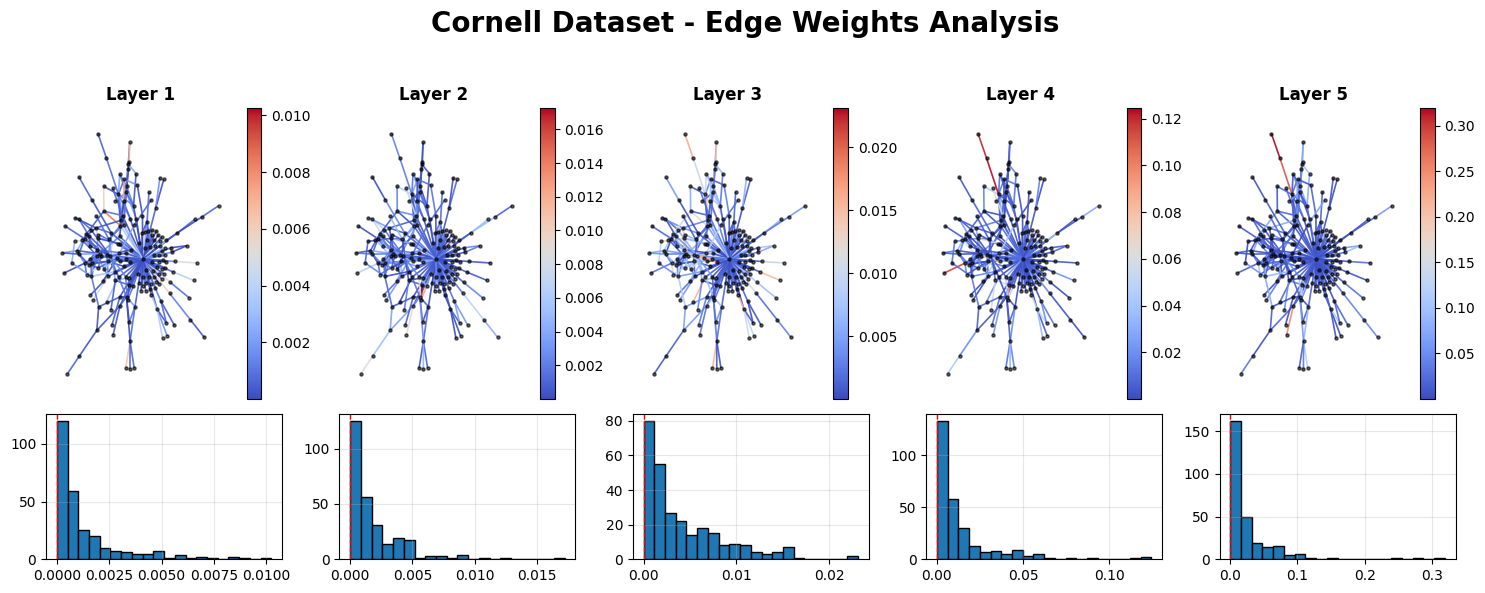

In [19]:
if dataset != "cora":
    G_ref = nx.Graph()
    for weight_dict in edge_weight_dict_list:
        for (u, v), w in weight_dict.items():
            G_ref.add_edge(u, v)

    pos_use = nx.spring_layout(G_ref, seed=42)

    plot_edge_curvature_simple(
        ricci_dict_list=edge_weight_dict_list,
        edge_weight_dict_list=edge_weight_dict_list,
        topological_curv_dict=None,
        G=G,
        pos_use=pos_use,
        cmap=plt.cm.coolwarm,
        bins=20,
        title=f"{dataset.capitalize()} Dataset - Edge Weights Analysis",
        save_image=True
    )

### 5.3 Cora-specific visual

In [20]:
# if dataset == "cora", we only plot the histograms

import numpy as np
import matplotlib.pyplot as plt

def plot_curvature_histograms_only(
    ricci_dict_list,
    topological_curv_dict=None,
    bins=40,
    figsize=None,
    global_range=True,
    density=True,
    title="Curvature Distributions",
    save_image=False
):
    layers = len(ricci_dict_list)
    n_cols = layers + (1 if topological_curv_dict is not None else 0)

    if figsize is None:
        figsize = (3 * n_cols, 3)

    # ------------------------------------------------------------
    # Collect all curvature values
    # ------------------------------------------------------------
    all_vals = []

    layer_vals_list = []
    for ricci_dict in ricci_dict_list:
        vals = np.array(list(ricci_dict.values()), dtype=float)
        vals = vals[np.isfinite(vals)]
        layer_vals_list.append(vals)
        if len(vals) > 0:
            all_vals.append(vals)

    if topological_curv_dict is not None:
        top_vals = np.array(list(topological_curv_dict.values()), dtype=float)
        top_vals = top_vals[np.isfinite(top_vals)]
        if len(top_vals) > 0:
            all_vals.append(top_vals)
    else:
        top_vals = None

    # ------------------------------------------------------------
    # Global range for comparability
    # ------------------------------------------------------------
    if global_range and len(all_vals) > 0:
        all_concat = np.concatenate(all_vals)
        xmin, xmax = np.min(all_concat), np.max(all_concat)
    else:
        xmin, xmax = None, None

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(1, n_cols, figsize=figsize, squeeze=False)

    for layer in range(layers):
        vals = layer_vals_list[layer]
        ax_curr = ax[0, layer]

        if len(vals) > 0:
            ax_curr.hist(
                vals,
                bins=bins,
                range=(xmin, xmax) if xmin is not None else None,
                edgecolor="black",
                density=density,
                alpha=0.85
            )
            ax_curr.axvline(0, color="red", linestyle="--", linewidth=1)

        ax_curr.set_title(f"Layer {layer+1}", fontsize=10, fontweight="bold")
        ax_curr.set_xlabel("Curvature")
        if layer == 0:
            ax_curr.set_ylabel("Density" if density else "Count")
        ax_curr.grid(alpha=0.3)

    # ------------------------------------------------------------
    # Last column: topological curvature
    # ------------------------------------------------------------
    if topological_curv_dict is not None:
        ax_curr = ax[0, layers]

        if len(top_vals) > 0:
            ax_curr.hist(
                top_vals,
                bins=bins,
                range=(xmin, xmax) if xmin is not None else None,
                edgecolor="black",
                density=density,
                alpha=0.85
            )
            ax_curr.axvline(0, color="red", linestyle="--", linewidth=1)

        ax_curr.set_title("Topological", fontsize=10, fontweight="bold")
        ax_curr.set_xlabel("Curvature")
        ax_curr.grid(alpha=0.3)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.9])

    if save_image:
        os.makedirs(f"./results/weights-experiments/{dataset}/{layers}-layers", exist_ok=True)
        fig.savefig(f"./results/weights-experiments/{dataset}/{layers}-layers/{title}.pdf", dpi=300)
    
    plt.show()

In [21]:
if dataset == "cora":
    plot_curvature_histograms_only(
        ricci_dict_list=edge_weight_dict_list,
        topological_curv_dict=topological_curv_dict,
        bins=30,
        figsize=(15, 4),
        global_range=True,
        density=False,
        title=f"{dataset.capitalize()} Dataset - Edge Weights Analysis",
        save_image=True
    )

## 6. Additional Analysis

In [22]:
# Adjacency matrix of the reference graph B
L0_LIST = []
L1_LIST = []
ev0_list = []
e0_list = []
f0_list = []

for df in DF_Lap:

    df = df.transpose().copy()
    # display(df)
    df.rename(columns={0: "source", 1: "target", 2: "value"}, inplace=True)
    df_new = df.pivot(index="source", columns="target", values="value").fillna(0)
    L0 = df_new.to_numpy()
    #display(L0)
    
    B0, F0 = fbc(L0)
    L0_LIST.append(L0)
    e0,ev0 = np.linalg.eigh(L0)
    ev0_list.append(ev0)
    e0_list.append(e0)
    f0_list.append(np.diag(F0))
    
B_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)

    B_list.append(B)

EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())


In [23]:
L1_LIST = []
f1_list = []
for B in B_list:

    L1 = B.T @ B
    print(L1)
    L1_LIST.append(L1)

    B1, F1 = fbc(L1)
    f1_list.append(np.diag(F1))

edge            (0.0, 42.0)  (1.0, 82.0)  (1.0, 90.0)  (1.0, 99.0)  \
edge                                                                 
(0.0, 42.0)        0.000921     0.000000     0.000000     0.000000   
(1.0, 82.0)        0.000000     0.002379     0.000473     0.001361   
(1.0, 90.0)        0.000000     0.000473     0.001823     0.000654   
(1.0, 99.0)        0.000000     0.001361     0.000654     0.002151   
(1.0, 148.0)       0.000000     0.000024     0.000011     0.000033   
...                     ...          ...          ...          ...   
(148.0, 154.0)     0.000000     0.000000     0.000000     0.000000   
(148.0, 167.0)     0.000000     0.000000     0.000000     0.000000   
(148.0, 178.0)     0.000000     0.000000     0.000000     0.000000   
(149.0, 167.0)     0.000000     0.000000     0.000000     0.000000   
(157.0, 160.0)     0.000000     0.000000     0.000000     0.000000   

edge            (1.0, 148.0)  (2.0, 42.0)  (3.0, 42.0)  (3.0, 163.0)  \
edge             

InvalidIndexError: (0, slice(None, None, None))

## Deprecated

In [ ]:
# G = nx.Graph()
# G.add_nodes_from(B.index)
# G.add_edges_from(list(B.columns))

In [ ]:
# pos_use = nx.spring_layout(G, seed=42)
# cmap    = plt.cm.coolwarm

# fig, ax = plt.subplots(2, layers + 1, figsize=(2*(layers + 1), 6),
#                        gridspec_kw={"height_ratios": [3, 1.5]})

# # ---------- One column per layer ----------
# for layer in range(layers):
#     curvatures = np.asarray(f0_list[layer])
#     norm       = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

#     nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layer], node_size=10, node_color=cmap(norm(curvatures)))
#     nx.draw_networkx_edges(G, pos_use, ax=ax[0, layer], width=0.5, alpha=0.2)
#     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layer])
#     ax[0, layer].set_title(f"Sheaf Curv Layer {layer+1}", fontweight="bold", fontsize=12)
#     ax[0, layer].axis("off")

#     ax[1, layer].hist(curvatures, bins=20, edgecolor="black")
#     ax[1, layer].axvline(0, color="red", linestyle="--", linewidth=1)
#     ax[1, layer].set_title(f"Histogram Layer {layer+1}", fontsize=10, fontweight="bold")
#     ax[1, layer].set_xlabel("0-curvature")
#     ax[1, layer].set_ylabel("Frequency")
#     ax[1, layer].grid(alpha=0.3)

# # ---------- Last column: f0_top ----------
# f0_top_arr = np.asarray(f0_top)
# norm       = plt.Normalize(vmin=f0_top_arr.min(), vmax=f0_top_arr.max())

# nx.draw_networkx_nodes(G, pos_use, ax=ax[0, layers], node_size=10, node_color=cmap(norm(f0_top_arr)))
# nx.draw_networkx_edges(G, pos_use, ax=ax[0, layers], width=0.5, alpha=0.2)
# plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax[0, layers])
# ax[0, layers].set_title("Sheaf Curv Top", fontweight="bold", fontsize=12)
# ax[0, layers].axis("off")

# ax[1, layers].hist(f0_top_arr, bins=20, edgecolor="black")
# ax[1, layers].axvline(0, color="red", linestyle="--", linewidth=1)
# ax[1, layers].set_title("Histogram Top", fontsize=10, fontweight="bold")
# ax[1, layers].set_xlabel("0-curvature")
# ax[1, layers].set_ylabel("Frequency")
# ax[1, layers].grid(alpha=0.3)

# fig.suptitle("Sheaf Curvature Analysis", fontsize=20, fontweight="bold")
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()